# **Getting Requirements**

This uses Python 3.10.x 

In [1]:
! pip install matplotlib pandas mplfinance marketprofile plotly yfinance-cache
! pip install yfinance --upgrade --no-cache-dir
! pip install --upgrade nbformat
! pip install IPython IPython notebook tabulate textblob

# **Imports**

In [2]:
from datetime import datetime, timedelta
import concurrent.futures
import logging
logging.basicConfig(level=40)

# Third-party imports
import json

import matplotlib.pyplot as plt
from tabulate import tabulate
from textblob import TextBlob

import mplfinance as mpf
import numpy as np
import time
from tqdm import tqdm
import nbformat
print(nbformat.__version__)
import pandas as pd
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
from IPython.display import Markdown
from IPython.display import display
import plotly.graph_objects as go

import yfinance as yf
# import yfinance_cache as yfc

# Local application/library specific imports
from market_profile import MarketProfile

5.10.3


# **Get all Companies from CSV and Fetch Initial Data**

In [3]:
file_path = './tickers.csv'  # Updated to a relative path for broader applicability

try:
    # Try loading the file. Adjust encoding if needed.
    data = pd.read_csv(file_path, encoding='ISO-8859-1')

    # Define the set of expected columns for validation.
    expected_columns = {'ticker'}

    # Check if the expected columns are present in the loaded data.
    if set(data.columns) & expected_columns == expected_columns:
        print('CSV file loaded successfully with the expected headers.')
        companies = data['ticker'].tolist()
    else:
        missing_columns = expected_columns - set(data.columns)
        print(f'CSV file is missing the following required columns: {missing_columns}')
        companies = []
except Exception as e:
    print(f'An error occurred while loading the CSV file: {e}')
    companies = []

# print("Total number of initial companies is: " + len(companies))

# Adjust or confirm the cache folder path as per your environment.
cache_folder = './colab_cache/'  # Adjusted to a more generic path unless you are specifically working within Google Colab.

def populate_metrics(ticker, metrics):
    if ticker and hasattr(ticker, 'info'):
        stock_info = ticker.info
        metrics['eps_values'].append(stock_info.get('trailingEps', 0))
        metrics['pe_values'].append(stock_info.get('trailingPE', 0))
        metrics['peg_values'].append(stock_info.get('trailingPegRatio', 0))
        metrics['gross_margins'].append(stock_info.get('grossMargins', 0))
        metrics['company_labels'].append(ticker.ticker)
    else:
        print(f"Skipped a company ticker due to missing info or an invalid object.")

def worker(company, metrics):
    try:
        ticker = yf.Ticker(company)
        populate_metrics(ticker, metrics)
    except Exception as e:
        print(f"Failed to fetch data for {company}. Error: {e}")

def fetch_metrics_data(companies):
    metrics = {metric: [] for metric in ['eps_values', 'pe_values', 'peg_values', 'gross_margins', 'company_labels']}

    with concurrent.futures.ThreadPoolExecutor(max_workers=10) as executor:
        futures = [executor.submit(worker, company, metrics) for company in companies]

        for i, future in enumerate(tqdm(concurrent.futures.as_completed(futures), total=len(companies), desc="Fetching metrics")):
            # This loop is primarily to keep tqdm updated, handling of results (if any) would go here

            # Pause for 2 seconds after every 500 requests
            if i != 0 and i % 1000 == 0:
                time.sleep(30)

    return metrics

# Example of usage
metrics = fetch_metrics_data(companies)

CSV file loaded successfully with the expected headers.


Fetching metrics: 100%|██████████| 3350/3350 [01:40<00:00, 33.23it/s]


# **Parametters**

In [4]:
days_history = 365 * 5  
interval_dates = '3mo'

eps_threshold = 5
gross_margin_threshold = 0.5 # 0.5 means 50%

peg_threshold_low = -0.1
peg_threshold_high = 1.1

def get_date_range(days_back):
    """Helper function to compute start and end date strings."""
    end_date = datetime.now()
    start_date = end_date - timedelta(days=days_back)
    return start_date.strftime('%Y-%m-%d'), end_date.strftime('%Y-%m-%d')

start_date_str, end_date_str = get_date_range(days_history)

# **Filtering Methods**

In [5]:
def filter_companies(metrics, eps_threshold, peg_threshold_low, peg_threshold_high, gross_margin_threshold):
    try:
        # Create DataFrame from metrics
        df = pd.DataFrame({
            'company': metrics['company_labels'],
            'eps': metrics['eps_values'],
            'pe': metrics['pe_values'],
            # 'ps': metrics['ps_values'],
            # 'pb': metrics['pb_values'],
            'peg': metrics['peg_values'],
            'gross_margin': metrics['gross_margins']
        })

        # Normalize gross margin if max is less than or equal to 1 (assuming it's in decimals rather than percentage)
        if df['gross_margin'].max() <= 1:
            df['gross_margin'] *= 100

        # Criteria for filtering - each condition needs to be enclosed in parentheses
        criteria = (df['eps'] > eps_threshold) & \
                   (df['gross_margin'] > gross_margin_threshold) & \
                   (df['peg'] > peg_threshold_low) & (df['peg'] <= peg_threshold_high) 

        # Apply criteria to filter DataFrame
        filtered_df = df[criteria]

        # Sort filtered DataFrame by 'pe' in ascending order
        filtered_df_sorted = filtered_df.sort_values(by='pe', ascending=True)

        # Print the filtered DataFrame
        print(f"Filtered down to {len(filtered_df_sorted)} companies based on criteria.")

        return filtered_df_sorted
    except Exception as e:
        print(f"An error occurred: {e}")
        return pd.DataFrame()

def classify_by_industry(tickers):
    industries = {}
    for ticker in tickers.tickers.values():
        sector = ticker.info.get('sector')
        if sector:
            industries.setdefault(sector, []).append(ticker.ticker)
    return industries

def fetch_industries(companies):
    tickers = yf.Tickers(' '.join(companies))
    industries = classify_by_industry(tickers)
    return industries

def fetch_recommendations_summary(ticker):
    """Fetch a structured summary of recommendations for a given ticker."""
    try:
        rec_data = ticker.get_recommendations_summary()
        if not rec_data.empty:
            return {row['period']: {
                'strongBuy': row['strongBuy'],
                'buy': row['buy'],
                'hold': row['hold'],
                'sell': row['sell'],
                'strongSell': row['strongSell']
            } for index, row in rec_data.iterrows()}
        else:
            return "No recommendation data available."
    except Exception as e:
        return f"Error: {str(e)}"


def populate_additional_metrics(ticker, metrics):
    """Populates a given metrics dictionary with data fetched from a ticker object."""
    stock_info = ticker.info

    # Existing metrics enhancements
    metrics['recommendations_summary'].append(fetch_recommendations_summary(ticker))  
    metrics['ps_values'].append(stock_info.get('priceToSalesTrailing12Months', 0))
    metrics['pb_values'].append(stock_info.get('priceToBook', 0))
    metrics['market_caps'].append(stock_info.get('marketCap', 0))

    # Additional metrics as per the new requirements
    fields_to_add = {
        'forwardPE': 'forwardPE',
        'profitMargins': 'profitMargins',
        'heldPercentInsiders': 'heldPercentInsiders',
        'heldPercentInstitutions': 'heldPercentInstitutions',
        'forwardEps': 'forwardEps',
        'recommendationMean': 'recommendationMean',
        'recommendationKey': 'recommendationKey',
        'numberOfAnalystOpinions': 'numberOfAnalystOpinions',
        'totalCashPerShare': 'totalCashPerShare',
        'debtToEquity': 'debtToEquity',
        'freeCashflow': None,  # Will be fetched from df
        'earningsGrowth': 'earningsGrowth',
        'revenueGrowth': 'revenueGrowth'
    }

    df = ticker.cashflow
    
    # We are assuming df has a row corresponding to the specific ticker we are fetching for
    free_cash_flow = df.iloc[0, :].tolist()  # Change to df.iloc[:, 0].values for np.array

    for key, value in fields_to_add.items():
        if key not in metrics:
            metrics[key] = []  # Initialize if key doesn't exist
        if key == 'freeCashflow':
            metrics[key].append(free_cash_flow)
        else:
            metrics[key].append(stock_info.get(value, 0))  # Append with a default of 0 if not found

    return metrics

def augment_metrics_with_live_data(companies, original_metrics):
    augmented_data = {metric: [] for metric in original_metrics}  # Prepare structure
    augmented_data.update({  # Prepare for additional data
        'recommendations_summary': [],
        'news': [],
        'ps_values': [],
        'pb_values': [],
        'market_caps': []
    })

    for company_symbol in companies:
        try:
            # Assuming you have a way to get a ticker object for the company symbol
            ticker = get_ticker_object(company_symbol)  # You'll need to define this based on your data source/API

            # Initialize an empty dict for individual company metrics
            company_metrics = {metric: [] for metric in augmented_data}

            # Use populate_additional_metrics to fill company_metrics with live data
            populate_additional_metrics(ticker, company_metrics)

            # Now, append or extend each key in company_metrics to augmented_data
            for key, value in company_metrics.items():
                if isinstance(value, list) and key in augmented_data:  # Handling list types specifically
                    augmented_data[key].extend(value)
                else:
                    augmented_data[key].append(value)
        except Exception as e:
            print(f"Error processing company {company_symbol}: {e}")
            # Handle missing data or errors as needed, possibly skipping or using placeholder data

    return augmented_data

def get_ticker_object(symbol):
    """
    Given a symbol, returns a Ticker object using the yfinance library.
    :param symbol: The stock symbol (e.g., 'AAPL' for Apple Inc.)
    :return: yfinance.Ticker object containing information about the symbol
    """
    ticker = yf.Ticker(symbol)
    return ticker

def fetch_additional_metrics_data(companies):
    """Fetches and structures various financial metrics for the given list of company tickers."""
    tickers = yf.Tickers(' '.join(companies))
    metrics = {metric: [] for metric in ['ps_values', 'pb_values',
                                     'market_caps', 'recommendations_summary']}
    metrics['price_diff'] = {}

    for company in companies:
        try:
            ticker = tickers.tickers[company]
            populate_additional_metrics(ticker, metrics)
        except KeyError:
            print(f"Warning: Ticker {company} not found. Skipping.")

    return metrics

def build_combined_metrics(filtered_company_symbols, metrics, metrics_filtered):
    # Remove 'companies_fetched' if present in both dictionaries
    metrics.pop('companies_fetched', None)
    metrics_filtered.pop('companies_fetched', None)

    # Initialize combined_metrics excluding 'company_labels' explicitly as it's handled separately
    combined_metrics = {key: [] for key in set(list(metrics.keys()) + list(metrics_filtered.keys())) - {'company_labels', 'companies_fetched'}}

    # Directly use 'filtered_company_symbols' as the authoritative list of companies
    combined_metrics['company_labels'] = filtered_company_symbols

    for symbol in filtered_company_symbols:
        # Derive index from 'company_labels' in 'metrics' if it exists
        metrics_index = metrics['company_labels'].index(symbol) if 'company_labels' in metrics and symbol in metrics['company_labels'] else -1

        for key in combined_metrics:
            if key == 'company_labels':  # Skip 'company_labels' here since it's already handled
                continue

            # Process metrics from the 'metrics' dictionary
            if key in metrics and metrics_index >= 0:
                if isinstance(metrics[key], list) and len(metrics[key]) > metrics_index:
                    combined_metrics[key].append(metrics[key][metrics_index])
                else:
                    combined_metrics[key].append(None)  # Handle missing or misaligned data

            # Process additional metrics from the 'metrics_filtered' dictionary
            elif key in metrics_filtered:
                # We assume 'metrics_filtered' directly mirrors 'filtered_company_symbols' in sequence
                filtered_index = filtered_company_symbols.index(symbol)
                if isinstance(metrics_filtered[key], list) and len(metrics_filtered[key]) > filtered_index:
                    combined_metrics[key].append(metrics_filtered[key][filtered_index])
                else:
                    combined_metrics[key].append(None)  # Handle missing or misaligned data
            else:
                # If the key doesn't exist in 'metrics' when processing, initialize missing entries with None
                if key not in metrics:
                    combined_metrics[key].append(None)

    return combined_metrics

filtered_companies_df = filter_companies(metrics, eps_threshold, peg_threshold_low, peg_threshold_high, gross_margin_threshold)

filtered_company_symbols = filtered_companies_df['company'].tolist()

metrics_filtered = fetch_additional_metrics_data(filtered_company_symbols)

combined_metrics = build_combined_metrics(filtered_company_symbols, metrics, metrics_filtered)

filtered_industries = fetch_industries(filtered_company_symbols)

Filtered down to 12 companies based on criteria.


In [6]:
def fetch_historical_data(ticker, start_date, end_date, period=None, interval=interval_dates):
    try:
        if period:
            data = ticker.history(period=period, interval=interval)
        else:
            data = ticker.history(start=start_date, end=end_date, interval=interval)
        return data
    except Exception as e:
        print(f"Error fetching data for {ticker}: {e}")
        return pd.DataFrame()  # Return an empty DataFrame

def calculate_price_diff(companies):
    tickers = yf.Tickers(' '.join(companies))
    price_diff = {}  # Store price difference info here

    for company in companies:
        ticker = tickers.tickers[company]
        hist = fetch_historical_data(ticker, None, None, period="1y")
        if not hist.empty:
            today_price = hist['Close'].iloc[-1]
            high_52week = max(hist['High'])
            low_52week = min(hist['Low'])
            high_percent_diff = ((today_price - high_52week) / high_52week) * 100
            low_percent_diff = ((today_price - low_52week) / low_52week) * 100
            price_diff[company] = {'high_diff': -1 * high_percent_diff, 'low_diff': low_percent_diff}

    return price_diff

def fetch_price_diff(companies, combined_metrics):
    price_diff = calculate_price_diff(companies)
    combined_metrics['price_diff'] = price_diff

    return combined_metrics

combined_metrics = fetch_price_diff(filtered_company_symbols, combined_metrics)

def plot_combined_interactive(combined_metrics):
    # Extract data for all plots
    company_labels = combined_metrics['company_labels']
    eps_values = combined_metrics['eps_values']
    high_diffs = [combined_metrics['price_diff'][company]['high_diff'] for company in company_labels]
    low_diffs = [combined_metrics['price_diff'][company]['low_diff'] for company in company_labels]
    market_caps = combined_metrics['market_caps']
    pb_values = combined_metrics['pb_values']
    pe_values = combined_metrics['pe_values']
    peg_values = combined_metrics['peg_values']
    ps_values = combined_metrics['ps_values']
    gross_margins = combined_metrics['gross_margins']
    recommendations_summary = combined_metrics['recommendations_summary']
    earningsGrowth = combined_metrics['earningsGrowth']
    revenueGrowth = combined_metrics['revenueGrowth']
    freeCashflow = combined_metrics['freeCashflow']

    # Normalize PEG sizes for Plot 4 visualization
    peg_min = min(peg_values)
    peg_max = max(peg_values)
    norm_peg_sizes = [(peg - peg_min) / (peg_max - peg_min) * 30 + 10 for peg in peg_values]

    fig = make_subplots(rows=3,  # Updated to 4 rows to include the desired 4th row
                            cols=3,
                            subplot_titles=("Price Difference % Over the Last Year",
                                            "EPS vs P/E Ratio",
                                            "Gross Margin (%)",
                                            "EPS vs P/B Ratio",
                                            "EPS vs PEG Ratio",
                                            "EPS vs P/S Ratio",
                                            "Upgrades & Downgrades Timeline",
                                            "Free Cash Flow",
                                            "Earnings Growth vs Revenue Growth",
                                            "Large Plot Spanning All Columns in 4th Row"),  # Added title for the large plot in the 4th row
                            specs=[
                                [{}, {}, {}],  # First row: 3 individual cells for plots
                                [{}, {}, {}],  # Second row: 3 individual cells for plots
                                [{}, {}, {}]  # Third row: 3 individual cells for plots
                            ],
                            vertical_spacing=0.1  # Adjust spacing for aesthetics
                        )

    colors = {company: f'hsl({(i / len(company_labels) * 360)},100%,50%)' for i, company in enumerate(company_labels)}

    ## sorting the gross margin bar charts
    sorted_data = sorted(zip(company_labels, gross_margins, colors), key=lambda x: x[1], reverse=True)  # Sort by gross_margin in descending order
    sorted_labels, sorted_gross_margins, sorted_colors = zip(*sorted_data)

    for i, company in enumerate(company_labels):
        legendgroup = f"group_{company}"
        marker_size = max(market_caps[i] / max(market_caps) * 50, 5)

        # Plot 1: Price Difference
        fig.add_trace(
            go.Scatter(
                x=[high_diffs[i]],
                y=[low_diffs[i]],
                marker=dict(size=10, color=colors[company]),
                legendgroup=legendgroup,
                name=company,
                hoverinfo='none',  # Disables default hover info, to use hovertemplate completely.
                hovertemplate=f'Company: {company}<br>High Diff: %{{x}}<br>Low Diff: %{{y}}<extra></extra>',  # Custom hover
            ),
            row=1, col=1
        )

        # Plot 2: EPS vs P/E Ratio
        fig.add_trace(
            go.Scatter(
                x=[eps_values[i]],
                y=[pe_values[i]],
                marker=dict(size=marker_size, color=colors[company]),
                legendgroup=legendgroup,
                showlegend=False,
                hoverinfo='none',
                hovertemplate=f'Company: {company}<br>EPS: ${eps_values[i]}<br>P/E Ratio: {pe_values[i]}<extra></extra>',  # Custom hover
            ),
            row=1, col=2
        )

        # Plot 3: Gross Margin Bar Chart
        fig.add_trace(go.Bar(
            x=[company_labels[i]],
            y=[gross_margins[i] * 100],
            marker=dict(color=colors[company]),
            legendgroup=legendgroup,
            showlegend=False,
            width=0.8  # Adjust this value as needed
        ), row=1, col=3)

        # Plot 4:  EPS vs P/B Ratio
        fig.add_trace(
            go.Scatter(
                x=[eps_values[i]],
                y=[pb_values[i]],
                marker=dict(size=marker_size, color=colors[company]),
                legendgroup=legendgroup,
                showlegend=False,
                hoverinfo='none',
                hovertemplate=f'Company: {company}<br>EPS: ${eps_values[i]}<br>P/B Ratio: {pb_values[i]}<extra></extra>',  # Custom hover
            ),
            row=2, col=1
        )

        # Plot 5:  EPS vs PEG Ratio
        fig.add_trace(
            go.Scatter(
                x=[eps_values[i]],
                y=[peg_values[i]],
                marker=dict(size=marker_size, color=colors[company]),
                legendgroup=legendgroup,
                showlegend=False,
                hoverinfo='none',
                hovertemplate=f'Company: {company}<br>EPS: ${eps_values[i]}<br>PEG Ratio: {peg_values[i]}<extra></extra>',
            ),
            row=2, col=2
        )

        # Plot 6:  EPS vs P/S Ratio
        fig.add_trace(
            go.Scatter(
                x=[eps_values[i]],
                y=[ps_values[i]],
                marker=dict(size=marker_size, color=colors[company]),
                legendgroup=legendgroup,
                showlegend=False,
                hoverinfo='none',
                hovertemplate=f'Company: {company}<br>EPS: ${eps_values[i]}<br>P/S Ratio: {ps_values[i]}<extra></extra>',  # Custom hover
            ),
            row=2, col=3
        )

        # Plot 7: Recommendations Summary
        current_recommendations = recommendations_summary[i]

        if isinstance(current_recommendations, dict) and '0m' in current_recommendations:
            ratings = current_recommendations['0m']
            rating_categories = ['strongBuy', 'buy', 'hold', 'sell', 'strongSell']
            rating_values = [ratings.get(category, 0) for category in rating_categories]

            # Preparing data for bar plot
            y_categories = list(rating_categories) # Convert category names to numeric values
            category_names = {index: name for index, name in enumerate(rating_categories)} # Map for axis ticks

            # Use the count as bar height
            bar_heights = rating_values

            # Add bar chart to the subplot
            fig.add_trace(
                go.Bar(
                    x=rating_categories,  # Categories on the x-axis
                    y=bar_heights,  # Corresponding values on the y-axis
                    marker=dict(color=colors[company]),
                    name=company,
                    legendgroup=legendgroup,
                    showlegend=False,
                    text=company,  # Display company names
                    hoverinfo='y+text'  # Show hover text and value
                ),
                row=3, col=1
            )

            fig.update_yaxes(range=[0, max(peg_values)], row=2, col=2)

            # If you want to apply a starting y-axis of 0 universally to all subplots, you could do:
            for row in range(1, 3):  # Adjust the range accordingly based on your actual number of rows
                for col in range(1, 3):  # Adjust the range accordingly based on your actual number of columns
                    # Use conditions or specific logic if some charts shouldn't start from 0
                    fig.update_yaxes(range=[0, "auto"], row=row, col=col)

        else:
            # Handle unexpected data structure
            continue

        # # Adjust the years to match the length of the data
        now = datetime.now()
        year = now.year

        # If today's date is before April first, we are still in Q1
        if now.month < 4:
            year -= 1

        years = [str(year - i) for i in range(3, -1, -1)]
        
        fig.add_trace(            
            go.Scatter(                
                x=years[:len(freeCashflow[i])],                 
                y=[cf for cf in freeCashflow[i]],                
                # mode="lines",                
                name=company_labels[i],  # Legend title                
                hoverinfo='none',                
                legendgroup=legendgroup,     
                showlegend=False,
                hovertemplate=f'Company: {company}<br>Year: %{{x}}<br> Free Cashflow: %{{y}}<extra></extra>',            
            ),            
            row=3, col=2        
        )         

        fig.add_trace(            
            go.Scatter(                
                x=[revenueGrowth[i]],                
                y=[earningsGrowth[i]],                
                marker=dict(size=10, color=colors[company]),                
                legendgroup=legendgroup,                
                showlegend=False,  # Hide from legend                
                hoverinfo='none',                
                hovertemplate=f'Company: {company}<br>Revenue Growth: {revenueGrowth[i]}<br>Earnings Growth: {earningsGrowth[i]}<extra></extra>',
            ),            
            row=3, col=3        
        )

    # Update axes titles
    titles = [
        ("High Diff (%)", "Low Diff (%)"),  # Plot 1
        ("EPS", "P/E Ratio"),  # Plot 2
        ("Company", "Gross Margin (%)"),  # Plot 3
        ("Price to Books", "EPS"),  # Plot 4
        ("PEG", "EPS"),  # Plot 5
        ("P/S", "EPS"),  # Plot 6
        ("Years", "Free Cash Flow"),  # Plot 7 (3,2) - assumed Free Cash Flow plot
        ("Earnings Growth", "Revenue Growth")  # Plot 8 (3,3)
        # Assuming Plot 9 doesn't require a title because of the 'colspan' attribute
    ]


    for col, (x_title, y_title) in enumerate(titles, start=1):
        fig.update_xaxes(title_text=x_title, row=1, col=col)
        fig.update_yaxes(title_text=y_title, row=1, col=col)

    fig.update_xaxes(title_text="Recommendation Type", row=1, col=4)
    fig.update_yaxes(title_text="Number of Recommendations", row=1, col=4)

    fig.update_layout(height=1500)

    # Layout adjustments for readability and aesthetics
    fig.update_layout(
        updatemenus=[
            dict(
                type="buttons",
                direction="left",
                buttons=list([
                    dict(
                        args=[{"visible": "legendonly"}],  # This sets non-selected traces to be hidden.
                        label="Hide All",
                        method="restyle"
                    ),
                    dict(
                        args=[{"visible": True}],  # This makes all traces visible.
                        label="Show All",
                        method="restyle"
                    ),
                ]),
                pad={"r": 10, "t": 10},
                showactive=True,
                x=0,
                xanchor="left",
                y=-0.15,
                yanchor="top"
            ),
        ]
    )
    # Show the combined plot
    fig.show()
    
# Extract company labels from 'price_diff' keys or another consistent source
company_labels = list(combined_metrics['company_labels'])

# Explicitly add 'company_labels' to 'metrics_filtered'
combined_metrics['company_labels'] = company_labels

plot_combined_interactive(combined_metrics)

# **Plot Sectors**

In [7]:
def plot_sector_distribution_interactive(industries, title):
    sector_counts = {sector: len(tickers) for sector, tickers in industries.items()}

    labels = list(sector_counts.keys())
    sizes = list(sector_counts.values())

    fig = go.Figure(data=[go.Pie(labels=labels, values=sizes, hole=.3)])

    fig.update_layout(
        title_text=title,
        annotations=[dict(text='Sectors', x=0.50, y=0.5, font_size=20, showarrow=False)]
    )

    fig.show()

plot_sector_distribution_interactive(filtered_industries, "Interactive Ticker Distribution by Sector for Filtered Tickers")
# plot_sector_distribution_interactive(industries, "Interactive Ticker Distribution by Sector for all Tickers")


# **Plotting charts**


# Sector: Energy

## NOG - Northern Oil and Gas, Inc.

https://www.noginc.com


Market Cap: 3937.073152 Millions USD

An error occurred when trying to fetch data for NOG


| Metric           | Value                            |
|:-----------------|:---------------------------------|
| Dividend Date    | 2024-04-30                       |
| Ex-Dividend Date | 2024-03-27                       |
| Earnings Date    | ['May 02, 2024', 'May 06, 2024'] |
| Earnings High    | 1.32                             |
| Earnings Low     | 0.94                             |
| Earnings Average | 1.13                             |
| Revenue High     | 525,430,000.00                   |
| Revenue Low      | 485,640,000.00                   |
| Revenue Average  | 503,720,000.00                   |

Northern Oil and Gas, Inc., an independent energy company, engages in the acquisition, exploration, exploitation, development, and production of crude oil and natural gas properties in the United States. It primarily holds interests in the Williston Basin, the Appalachian Basin, and the Permian Basin in the United States. The company is based in Minnetonka, Minnesota.

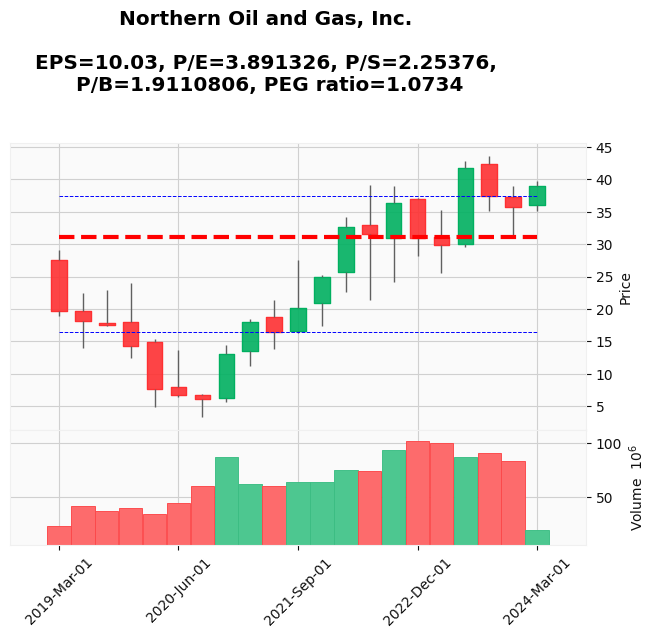

## CRC - California Resources Corporatio

https://www.crc.com


Market Cap: 3648.495616 Millions USD

|    | Title                                                                                                                                                                                                              | Publisher       |   Sentiment |   Days Ago |
|---:|:-------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------|:----------------|------------:|-----------:|
|  0 | [California Resources Corp. Nominates Christian Kendall to Board of Directors](https://finance.yahoo.com/news/california-resources-corp-nominates-christian-161331956.html)                                        | Hart Energy     |        0    |          3 |
|  1 | [California Resources Corporation Announces the Nomination of Christian S. Kendall to Its Board of Directors](https://finance.yahoo.com/news/california-resources-corporation-announces-nomination-130000316.html) | Business Wire   |        0    |          5 |
|  2 | [Berry Bolts On More California Assets as Kern County M&A Continues](https://finance.yahoo.com/news/berry-bolts-more-california-assets-154456369.html)                                                             | Hart Energy     |        0.5  |         18 |
|  3 | [California Resources Corporation (NYSE:CRC) Looks Interesting, And It's About To Pay A Dividend](https://finance.yahoo.com/news/california-resources-corporation-nyse-crc-124622536.html)                         | Simply Wall St. |        0.5  |         22 |
|  4 | [California Resources Corporation (NYSE:CRC) Q4 2023 Earnings Call Transcript](https://finance.yahoo.com/news/california-resources-corporation-nyse-crc-141256258.html)                                            | Insider Monkey  |        0    |         24 |
|  5 | [California Resources Full Year 2023 Earnings: Beats Expectations](https://finance.yahoo.com/news/california-resources-full-2023-earnings-102120859.html)                                                          | Simply Wall St. |        0.35 |         24 |
|  6 | [Here's What Key Metrics Tell Us About California Resources Corporation (CRC) Q4 Earnings](https://finance.yahoo.com/news/heres-key-metrics-tell-us-000007394.html)                                                | Zacks           |        0    |         25 |
|  7 | [California Resources Corporation (CRC) Q4 Earnings Miss Estimates](https://finance.yahoo.com/news/california-resources-corporation-crc-q4-233504823.html)                                                         | Zacks           |        0    |         25 |

| Metric           | Value                              |
|:-----------------|:-----------------------------------|
| Dividend Date    | 2024-03-18                         |
| Ex-Dividend Date | 2024-03-05                         |
| Earnings Date    | ['April 29, 2024', 'May 03, 2024'] |
| Earnings High    | 1.28                               |
| Earnings Low     | 0.52                               |
| Earnings Average | 0.84                               |
| Revenue High     | 922,340,000.00                     |
| Revenue Low      | 467,000,000.00                     |
| Revenue Average  | 645,710,000.00                     |

California Resources Corporation operates as an independent oil and natural gas exploration and production, and carbon management company in the United States. The company explores, produces, and markets crude oil, natural gas, and natural gas liquids for marketers, California refineries, and other purchasers that have access to transportation and storage facilities. It also engages in the generation and sale of electricity to the wholesale power market and utility sector; and developing various carbon capture and storage projects in California. The company was incorporated in 2014 and is based in Long Beach, California.

<Figure size 640x480 with 0 Axes>

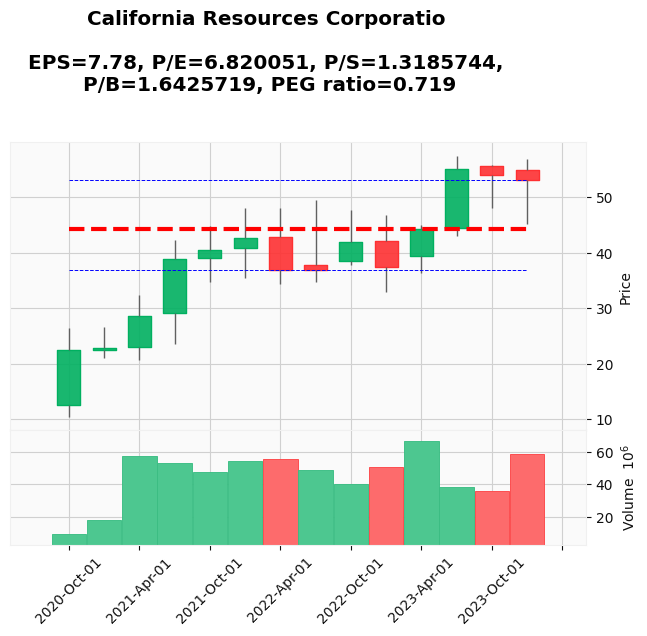

## SM - SM Energy Company

https://sm-energy.com


Market Cap: 5636.878848 Millions USD

|    | Title                                                                                                                                                                           | Publisher                |   Sentiment |   Days Ago |
|---:|:--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------|:-------------------------|------------:|-----------:|
|  0 | [Why Is SM Energy (SM) Up 18.1% Since Last Earnings Report?](https://finance.yahoo.com/news/why-sm-energy-sm-18-153042513.html)                                                 | Zacks                    |    0        |          2 |
|  1 | [An Intrinsic Calculation For SM Energy Company (NYSE:SM) Suggests It's 32% Undervalued](https://finance.yahoo.com/news/intrinsic-calculation-sm-energy-company-103512884.html) | Simply Wall St.          |    0        |          4 |
|  2 | [SM Energy Company Just Recorded A 12% EPS Beat: Here's What Analysts Are Forecasting Next](https://finance.yahoo.com/news/sm-energy-company-just-recorded-142431305.html)      | Simply Wall St.          |    0        |         29 |
|  3 | [SM Energy (SM) Q4 Earnings Top Estimates, Revenues Decline Y/Y](https://finance.yahoo.com/news/sm-energy-sm-q4-earnings-171500748.html)                                        | Zacks                    |    0.5      |         31 |
|  4 | [SM Energy Company (NYSE:SM) Q4 2023 Earnings Call Transcript](https://finance.yahoo.com/news/sm-energy-company-nyse-sm-150607087.html)                                         | Insider Monkey           |    0        |         31 |
|  5 | [Compared to Estimates, SM Energy (SM) Q4 Earnings: A Look at Key Metrics](https://finance.yahoo.com/news/compared-estimates-sm-energy-sm-013004050.html)                       | Zacks                    |    0        |         31 |
|  6 | [SM Energy: Q4 Earnings Snapshot](https://finance.yahoo.com/news/sm-energy-q4-earnings-snapshot-223241683.html)                                                                 | Associated Press Finance |    0        |         31 |
|  7 | [SM Energy Co (SM) Reports Record Net Proved Reserves and Strong Financial Performance for Full ...](https://finance.yahoo.com/news/sm-energy-co-sm-reports-215300048.html)     | GuruFocus.com            |    0.195833 |         32 |

| Metric           | Value                                |
|:-----------------|:-------------------------------------|
| Dividend Date    | 2024-02-05                           |
| Ex-Dividend Date | 2024-01-18                           |
| Earnings Date    | ['April 25, 2024', 'April 29, 2024'] |
| Earnings High    | 1.34                                 |
| Earnings Low     | 1.08                                 |
| Earnings Average | 1.24                                 |
| Revenue High     | 584,790,000.00                       |
| Revenue Low      | 514,250,000.00                       |
| Revenue Average  | 556,170,000.00                       |

SM Energy Company, an independent energy company, engages in the acquisition, exploration, development, and production of oil, gas, and natural gas liquids in the state of Texas. It has working interests in oil and gas producing wells in the Midland Basin and South Texas. The company was formerly known as St. Mary Land & Exploration Company and changed its name to SM Energy Company in May 2010. SM Energy Company was founded in 1908 and is headquartered in Denver, Colorado.

<Figure size 640x480 with 0 Axes>

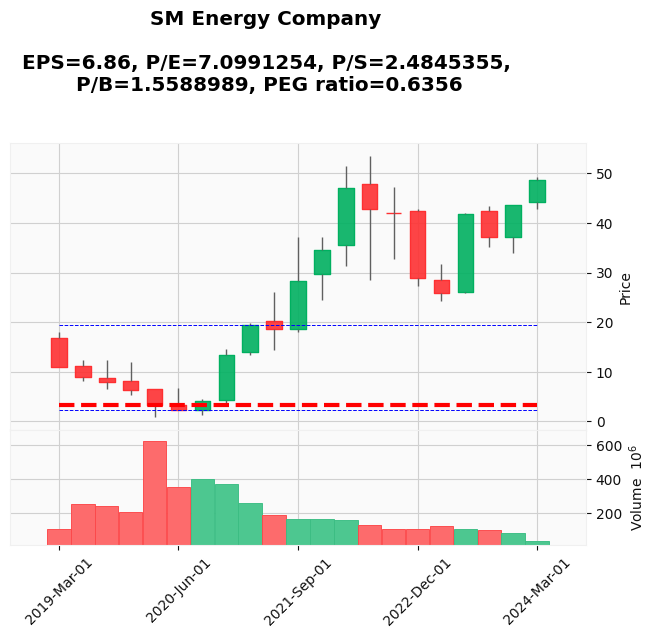

# Sector: Financial Services

## AMG - Affiliated Managers Group, Inc.

https://www.amg.com


Market Cap: 5369.377792 Millions USD

|    | Title                                                                                                                                                                                                                 | Publisher   |   Sentiment |   Days Ago |
|---:|:----------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------|:------------|------------:|-----------:|
|  0 | [Is Affiliated Managers Group (AMG) Outperforming Other Finance Stocks This Year?](https://finance.yahoo.com/news/affiliated-managers-group-amg-outperforming-144139882.html)                                         | Zacks       |   -0.125    |          3 |
|  1 | [Are Investors Undervaluing Affiliated Managers Group (AMG) Right Now?](https://finance.yahoo.com/news/investors-undervaluing-affiliated-managers-group-134015183.html)                                               | Zacks       |    0.285714 |          3 |
|  2 | [The Zacks Analyst Blog Highlights SEI Investments, Artisan Partners, KKR, T. Rowe and Affiliated Managers](https://finance.yahoo.com/news/zacks-analyst-blog-highlights-sei-110000106.html)                          | Zacks       |    0        |          3 |
|  3 | [Zacks.com featured highlights PagSeguro Digital, Affiliated Managers, Cigna, Barrett Business Services and Fidelis Insurance](https://finance.yahoo.com/news/zacks-com-featured-highlights-pagseguro-113400937.html) | Zacks       |    0        |          6 |
|  4 | [5 Low Price-to-Sales Stocks to Fetch Solid Portfolio Gains](https://finance.yahoo.com/news/5-low-price-sales-stocks-115000935.html)                                                                                  | Zacks       |    0        |          9 |
|  5 | [MarketAxess (MKTX) Uses EM Platform to Boost Brazil Presence](https://finance.yahoo.com/news/marketaxess-mktx-uses-em-platform-163400513.html)                                                                       | Zacks       |    0        |         11 |
|  6 | [Buy These 5 Stocks With Low P/B Ratio in March](https://finance.yahoo.com/news/buy-5-stocks-low-p-130900447.html)                                                                                                    | Zacks       |    0        |         11 |
|  7 | [4 Low Price-to-Cash Flow Stocks to Garner Superior Returns](https://finance.yahoo.com/news/4-low-price-cash-flow-115500120.html)                                                                                     | Zacks       |    0.35     |         13 |

| Metric           | Value                              |
|:-----------------|:-----------------------------------|
| Dividend Date    | 2024-02-29                         |
| Ex-Dividend Date | 2024-02-14                         |
| Earnings Date    | ['April 29, 2024', 'May 03, 2024'] |
| Earnings High    | 5.21                               |
| Earnings Low     | 4.53                               |
| Earnings Average | 5.04                               |
| Revenue High     | 538,400,000.00                     |
| Revenue Low      | 512,330,000.00                     |
| Revenue Average  | 521,120,000.00                     |

Affiliated Managers Group, Inc., through its affiliates, operates as an investment management company providing investment management services to mutual funds, institutional clients,retails and high net worth individuals in the United States. It provides advisory or sub-advisory services to mutual funds. These funds are distributed to retail, high net worth and institutional clients directly and through intermediaries, including independent investment advisors, retirement plan sponsors, broker-dealers, major fund marketplaces, and bank trust departments. The company also offers investment products in various investment styles in the institutional distribution channel, including small, small/mid, mid, and large capitalization value and growth equity, and emerging markets. In addition, it offers quantitative, alternative, and fixed income products, and manages assets for foundations and endowments, defined benefit, and defined contribution plans for corporations and municipalities. Affiliated Managers Group provides investment management or customized investment counseling and fiduciary services. Affiliated Managers Group, Inc. was formed in 1993 and is based in West Palm Beach, Florida with additional offices in Prides Crossing, Massachusetts; Stamford, Connecticut; London, United Kingdom; Dubai, United Arab Emirates; Sydney, Australia; Hong Kong; Tokyo, Japan, Zurich, Switzerland and Delaware.

<Figure size 640x480 with 0 Axes>

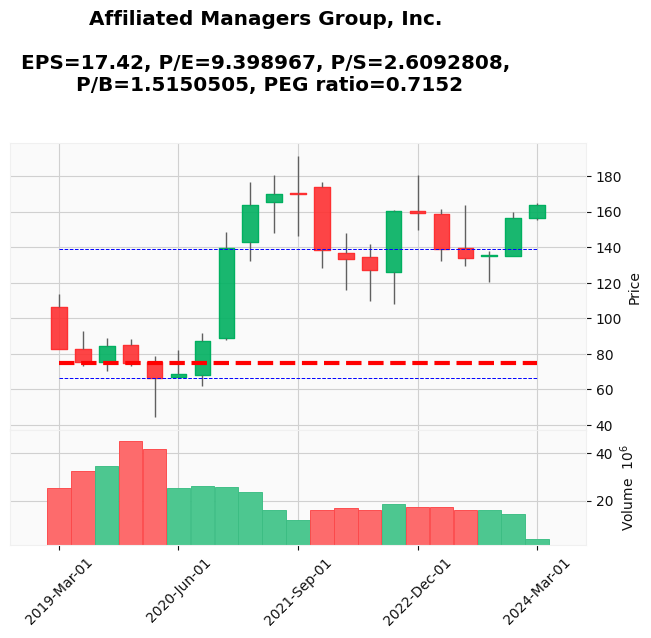

# Sector: Technology

## IDCC - InterDigital, Inc.

https://www.interdigital.com


Market Cap: 2673.628416 Millions USD

|    | Title                                                                                                                                                                                                                            | Publisher     |   Sentiment |   Days Ago |
|---:|:---------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------|:--------------|------------:|-----------:|
|  0 | [Here is What to Know Beyond Why InterDigital, Inc. (IDCC) is a Trending Stock](https://finance.yahoo.com/news/know-beyond-why-interdigital-inc-130016885.html)                                                                  | Zacks         |    0        |          2 |
|  1 | [InterDigital (IDCC) Ascends But Remains Behind Market: Some Facts to Note](https://finance.yahoo.com/news/interdigital-idcc-ascends-remains-behind-214518618.html)                                                              | Zacks         |   -0.4      |          4 |
|  2 | [InterDigital Declares Regular Quarterly Cash Dividend](https://finance.yahoo.com/news/interdigital-declares-regular-quarterly-cash-203000972.html)                                                                              | GlobeNewswire |    0        |          4 |
|  3 | [InterDigital’s Xiaofei Wang Appointed Chair of the IEEE 802.11 Artificial Intelligence and Machine Learning (AIML) Standing Committee](https://finance.yahoo.com/news/interdigital-xiaofei-wang-appointed-chair-080000680.html) | GlobeNewswire |   -0.6      |          4 |
|  4 | [InterDigital Inc's Chief Licensing Officer Eeva Hakoranta Sells Company Shares](https://finance.yahoo.com/news/interdigital-incs-chief-licensing-officer-230032933.html)                                                        | GuruFocus.com |    0        |          4 |
|  5 | [Wall Street Analysts Think InterDigital (IDCC) Is a Good Investment: Is It?](https://finance.yahoo.com/news/wall-street-analysts-think-interdigital-133010480.html)                                                             | Zacks         |    0.7      |          5 |
|  6 | [EchoStar (SATS) Hughes JUPITER System Implemented by Nilesat](https://finance.yahoo.com/news/echostar-sats-hughes-jupiter-system-130600894.html)                                                                                | Zacks         |    0        |          6 |
|  7 | [IDCC or QCOM: Which Is the Better Value Stock Right Now?](https://finance.yahoo.com/news/idcc-qcom-better-value-stock-154008188.html)                                                                                           | Zacks         |    0.392857 |          9 |

| Metric           | Value                            |
|:-----------------|:---------------------------------|
| Dividend Date    | 2024-04-24                       |
| Ex-Dividend Date | 2024-04-09                       |
| Earnings Date    | ['May 02, 2024', 'May 06, 2024'] |
| Earnings High    | 2.82                             |
| Earnings Low     | 2.7                              |
| Earnings Average | 2.75                             |
| Revenue High     | 250,800,000.00                   |
| Revenue Low      | 250,000,000.00                   |
| Revenue Average  | 250,280,000.00                   |

InterDigital, Inc. operates as a global research and development company with focus primarily on wireless, visual, artificial intelligence (AI), and related technologies. The company engages in the design and development of technologies that enable connected in a range of communications and entertainment products and services, which are licensed to companies providing such products and services, including makers of wireless communications, consumer electronics, IoT devices, and cars and other motor vehicles, as well as providers of cloud-based services, such as video streaming. It designs and develops a range of innovations for use in digital cellular and wireless products and networks, including 2G, 3G, 4G, 5G, and IEEE 802-related products and networks. The company also develops cellular technologies, such as technologies related to CDMA, TDMA, OFDM/OFDMA, and MIMO for use in 2G, 3G, 4G, and 5G wireless networks, as well as mobile terminal devices; and 3GPP technology portfolio in 5G, 5G, advanced and 6G, as well as technologies for automobiles, wearables, smart homes, drones, and other connected consumer electronic products. In addition, it provides video coding and transmission technologies; and engages in the research and development of artificial intelligence and machine learning solutions. Further, the company's patented technologies are used in various products that include smartphones, tablets, consumer electronics, and base stations; televisions, laptops, gaming consoles, set-top boxes, streaming devices, and connected automobiles. InterDigital, Inc. was incorporated in 1972 and is headquartered in Wilmington, Delaware.

<Figure size 640x480 with 0 Axes>

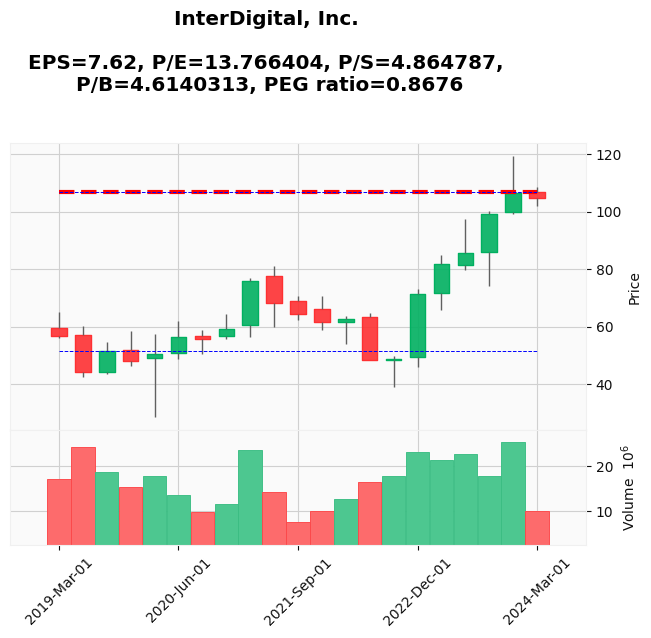

# Sector: Consumer Cyclical

## PVH - PVH Corp.

https://www.pvh.com


Market Cap: 8012.29824 Millions USD

|    | Title                                                                                                                                                                                | Publisher                 |   Sentiment |   Days Ago |
|---:|:-------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------|:--------------------------|------------:|-----------:|
|  0 | [20 Best Feminine Perfumes For Everyday Use](https://finance.yahoo.com/news/20-best-feminine-perfumes-everyday-213258889.html)                                                       | Insider Monkey            |        0.4  |          0 |
|  1 | [Carnival (CCL) to Report Q1 Earnings: What's in the Cards?](https://finance.yahoo.com/news/carnival-ccl-report-q1-earnings-144200523.html)                                          | Zacks                     |        0    |          2 |
|  2 | [What's in Store for DouYu International (DOYU) in Q4 Earnings?](https://finance.yahoo.com/news/whats-store-douyu-international-doyu-142200331.html)                                 | Zacks                     |        0    |          2 |
|  3 | [Columbia Sportswear (COLM) Hurt by Soft Demand, High Costs](https://finance.yahoo.com/news/columbia-sportswear-colm-hurt-soft-130900292.html)                                       | Zacks                     |        0.13 |          3 |
|  4 | [Guess? (GES) Q4 Earnings & Revenues Top Estimates, Grow Y/Y](https://finance.yahoo.com/news/guess-ges-q4-earnings-revenues-130300046.html)                                          | Zacks                     |        0.5  |          3 |
|  5 | [Dow Jones Futures Rise, Extend Fed-Led Rally, Micron Soars; 7 Stocks In Buy Areas](https://finance.yahoo.com/m/867ce100-af3f-3cd0-bd2e-5dfa3add1879/dow-jones-futures-rise%2C.html) | Investor's Business Daily |        0    |          3 |
|  6 | [Is a Surprise Coming for PVH Corp (PVH) This Earnings Season?](https://finance.yahoo.com/news/surprise-coming-pvh-corp-pvh-125400687.html)                                          | Zacks                     |        0    |          5 |
|  7 | [PVH Corp. to Host Conference Call to Discuss Fourth Quarter and Year-End 2023 Earnings Results](https://finance.yahoo.com/news/pvh-corp-host-conference-call-130000750.html)        | Business Wire             |        0    |          6 |

| Metric           | Value              |
|:-----------------|:-------------------|
| Dividend Date    | 2024-03-27         |
| Ex-Dividend Date | 2024-03-05         |
| Earnings Date    | ['April 01, 2024'] |
| Earnings High    | 3.74               |
| Earnings Low     | 3.45               |
| Earnings Average | 3.52               |
| Revenue High     | 2,480,000,000.00   |
| Revenue Low      | 2,401,000,000.00   |
| Revenue Average  | 2,419,100,000.00   |

PVH Corp. operates as an apparel company in the United States and internationally. The company operates through six segments: Tommy Hilfiger North America, Tommy Hilfiger International, Calvin Klein North America, Calvin Klein International, Heritage Brands Wholesale, and Heritage Brands Retail. It designs, markets, and retails men's, women's, and children's apparel and accessories, include branded dress shirts, neckwear, sportswear, jeans wear, performance apparel, intimate apparel, underwear, swimwear, swim-related products, handbags, accessories, footwear, outerwear, home furnishings, luggage products, sleepwear, loungewear, hats, scarves, gloves, socks, watches and jewelry, eyeglasses and non-ophthalmic sunglasses, fragrance, home bed and bath furnishings, small leather goods, and other products. The company offers its products under its own brands, such as Tommy Hilfiger, Calvin Klein, Van Heusen, IZOD, ARROW, Warner's, Olga, Geoffrey Beene, and True&Co., as well as various other owned, licensed, and private label brands. The company distributes its products at wholesale in department, chain, and specialty stores, as well as through warehouse clubs, mass market, and off-price and independent retailers; and through company-operated full-price, outlet stores, and concession locations, as well as through digital commerce sites. PVH Corp. was founded in 1881 and is based in New York, New York.

<Figure size 640x480 with 0 Axes>

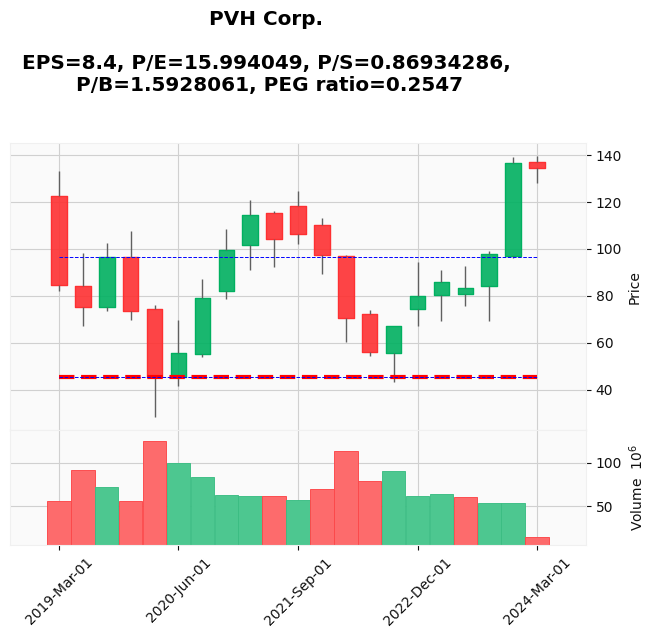

## EXPE - Expedia Group, Inc.

https://www.expediagroup.com


Market Cap: 18649.649152 Millions USD

|    | Title                                                                                                                                                       | Publisher      |   Sentiment |   Days Ago |
|---:|:------------------------------------------------------------------------------------------------------------------------------------------------------------|:---------------|------------:|-----------:|
|  0 | [30 Countries With Most Paid Vacation Days Per Year](https://finance.yahoo.com/news/30-countries-most-paid-vacation-200646300.html)                         | Insider Monkey |      0.5    |          0 |
|  1 | [Why the Market Dipped But Expedia (EXPE) Gained Today](https://finance.yahoo.com/news/why-market-dipped-expedia-expe-221520610.html)                       | Zacks          |      0      |          1 |
|  2 | [20 Most Underrated Travel Destinations in Asia](https://finance.yahoo.com/news/20-most-underrated-travel-destinations-003225715.html)                      | Insider Monkey |      0.5    |          4 |
|  3 | [Should You Hold Expedia (EXPE) for the Long Term?](https://finance.yahoo.com/news/hold-expedia-expe-long-term-124145213.html)                              | Insider Monkey |     -0.05   |          5 |
|  4 | [20 Most Visited States in the US by Foreign Travelers](https://finance.yahoo.com/news/20-most-visited-states-us-224841257.html)                            | Insider Monkey |      0.1875 |          5 |
|  5 | [25 Biggest Countries in Do Not Travel List](https://finance.yahoo.com/news/25-biggest-countries-not-travel-235716352.html)                                 | Insider Monkey |      0      |          6 |
|  6 | [Expedia (EXPE) Rises As Market Takes a Dip: Key Facts](https://finance.yahoo.com/news/expedia-expe-rises-market-takes-221519677.html)                      | Zacks          |      0      |          9 |
|  7 | [Turbulence Ahead? 3 Travel Stocks to Scrutinize After the Expedia Layoffs](https://finance.yahoo.com/news/turbulence-ahead-3-travel-stocks-173425405.html) | InvestorPlace  |      0      |         10 |

| Metric           | Value                            |
|:-----------------|:---------------------------------|
| Dividend Date    | 2020-03-26                       |
| Ex-Dividend Date | 2020-03-09                       |
| Earnings Date    | ['May 02, 2024', 'May 06, 2024'] |
| Earnings High    | 0.27                             |
| Earnings Low     | -1.37                            |
| Earnings Average | -0.24                            |
| Revenue High     | 2,920,670,000.00                 |
| Revenue Low      | 2,779,000,000.00                 |
| Revenue Average  | 2,812,590,000.00                 |

Expedia Group, Inc. operates as an online travel company in the United States and internationally. The company operates through B2C, B2B, and trivago segments. Its B2C segment includes Brand Expedia, a full-service online travel brand offers various travel products and services; Hotels.com for lodging accommodations; Vrbo, an online marketplace for the alternative accommodations; Orbitz, Travelocity, Wotif Group, ebookers, CheapTickets, Hotwire.com and CarRentals.com. The company's B2B segment provides various travel and non-travel companies including airlines, offline travel agents, online retailers, corporate travel management, and financial institutions who leverage its travel technology and tap into its diverse supply to augment their offerings and market Expedia Group rates and availabilities to its travelers. Its trivago segment, a hotel metasearch website, which send referrals to online travel companies and travel service providers from hotel metasearch websites. In addition, the company provides brand advertising through online and offline channels, loyalty programs, mobile apps, and search engine marketing, as well as metasearch, social media, direct and personalized traveler communications on its websites, and through direct e-mail communication with its travelers. The company was formerly known as Expedia, Inc. and changed its name to Expedia Group, Inc. in March 2018. Expedia Group, Inc. was founded in 1996 and is headquartered in Seattle, Washington.

<Figure size 640x480 with 0 Axes>

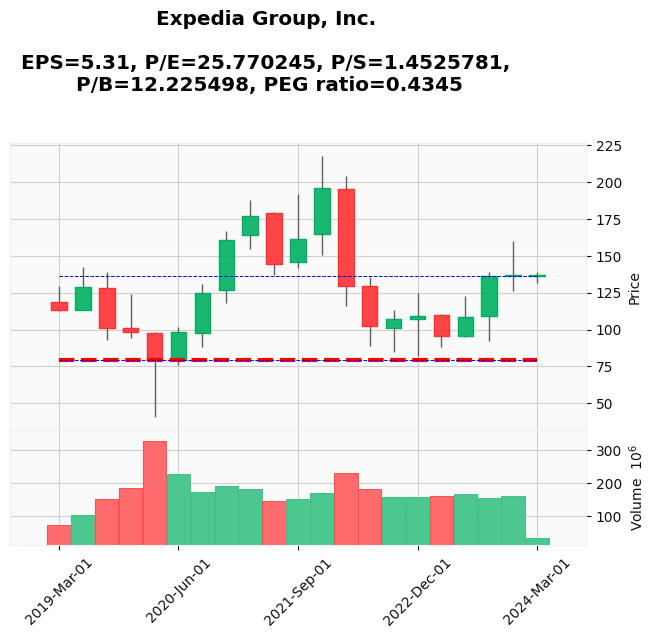

## BKNG - Booking Holdings Inc. Common St

https://www.bookingholdings.com


Market Cap: 123860.647936 Millions USD

|    | Title                                                                                                                                                                     | Publisher           |   Sentiment |   Days Ago |
|---:|:--------------------------------------------------------------------------------------------------------------------------------------------------------------------------|:--------------------|------------:|-----------:|
|  0 | [16 Most Undervalued Growth Stocks To Buy According To Hedge Funds](https://finance.yahoo.com/news/16-most-undervalued-growth-stocks-135418557.html)                      | Insider Monkey      |       0.5   |          0 |
|  1 | [Top 12 Stocks in George Soros’ Stock Portfolio](https://finance.yahoo.com/news/top-12-stocks-george-soros-131922971.html)                                                | Insider Monkey      |       0.5   |          0 |
|  2 | [Top Analyst Reports for Booking Holdings, Mitsubishi UFJ & Micron Technology](https://finance.yahoo.com/news/top-analyst-reports-booking-holdings-193300393.html)        | Zacks               |       0.5   |          2 |
|  3 | [Corporate Insiders are Dumping These 11 Tech Stocks](https://finance.yahoo.com/news/corporate-insiders-dumping-11-tech-192544428.html)                                   | Insider Monkey      |       0     |          2 |
|  4 | [Michael Burry’s Top 15 Stock Picks For 2024](https://finance.yahoo.com/news/michael-burry-top-15-stock-131339807.html)                                                   | Insider Monkey      |       0.5   |          2 |
|  5 | [Booking Holdings (BKNG) Rises Higher Than Market: Key Facts](https://finance.yahoo.com/news/booking-holdings-bkng-rises-higher-221521621.html)                           | Zacks               |       0.125 |          2 |
|  6 | [Agoda, GSTC, and USAID Partner to Champion Sustainability Education for Hotels in Asia](https://finance.yahoo.com/news/agoda-gstc-usaid-partner-champion-061700349.html) | PR Newswire         |       0     |          3 |
|  7 | [Goodbye, Magnificent Seven. Who are tech's 'Electric Eleven'?](https://finance.yahoo.com/video/goodbye-magnificent-seven-techs-electric-213204281.html)                  | Yahoo Finance Video |       1     |          4 |

| Metric           | Value                            |
|:-----------------|:---------------------------------|
| Dividend Date    | 2024-03-28                       |
| Ex-Dividend Date | 2024-03-07                       |
| Earnings Date    | ['May 02, 2024', 'May 06, 2024'] |
| Earnings High    | 16.17                            |
| Earnings Low     | 9.7                              |
| Earnings Average | 14.07                            |
| Revenue High     | 4,308,000,000.00                 |
| Revenue Low      | 4,148,000,000.00                 |
| Revenue Average  | 4,245,450,000.00                 |

Booking Holdings Inc., together with its subsidiaries, provides online and traditional travel and restaurant reservations and related services in the United States, the Netherlands, and internationally. The company operates Booking.com, which offers online accommodation reservations; and Priceline, which provides online travel reservation services, as well as consumers hotel, flight, activity, rental car reservation, vacation packages, cruises, and hotel distribution services. It also operates Agoda that offers online accommodation reservation, flight, ground transportation, and activities reservation services. In addition, the company operates KAYAK, an online meta-search service that allows consumers to search and compare travel itineraries and prices; OpenTable for booking online restaurant reservations, as well as reservation management services to restaurants; and Rentalcars.com. Further, it offers travel-related insurance products and restaurant management services to consumers, travel service providers, and restaurants; and advertising services. The company was formerly known as The Priceline Group Inc. and changed its name to Booking Holdings Inc. in February 2018. Booking Holdings Inc. was founded in 1997 and is headquartered in Norwalk, Connecticut.

<Figure size 640x480 with 0 Axes>

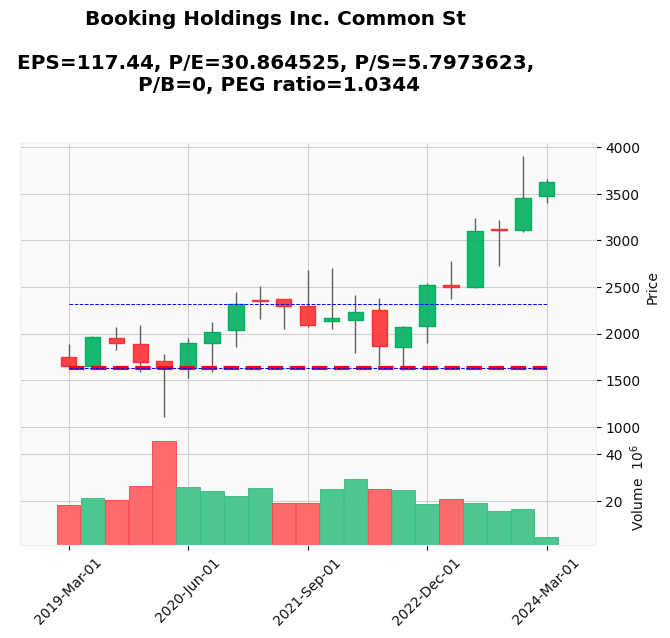

# Sector: Communication Services

## NXST - Nexstar Media Group, Inc.

https://www.nexstar.tv


Market Cap: 5507.679232 Millions USD

|    | Title                                                                                                                                                                                         | Publisher      |   Sentiment |   Days Ago |
|---:|:----------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------|:---------------|------------:|-----------:|
|  0 | [Insider Sell: EVP, Chief Revenue Officer Michael Strober Sells 1,000 Shares of Nexstar Media ...](https://finance.yahoo.com/news/insider-sell-evp-chief-revenue-052611684.html)              | GuruFocus.com  |    0        |          1 |
|  1 | [Michael Burry’s Top 15 Stock Picks For 2024](https://finance.yahoo.com/news/michael-burry-top-15-stock-131339807.html)                                                                       | Insider Monkey |    0.5      |          2 |
|  2 | [Director Lisbeth Mcnabb Sells 2,500 Shares of Nexstar Media Group Inc (NXST)](https://finance.yahoo.com/news/director-lisbeth-mcnabb-sells-2-230034188.html)                                 | GuruFocus.com  |    0        |          2 |
|  3 | [Nexstar Media Releases Statement on FCC Ruling Regarding Its Relationship With WPIX-TV](https://finance.yahoo.com/news/nexstar-media-releases-statement-fcc-214000226.html)                  | Business Wire  |    0        |          3 |
|  4 | [Director Lisbeth Mcnabb Sells Shares of Nexstar Media Group Inc (NXST)](https://finance.yahoo.com/news/director-lisbeth-mcnabb-sells-shares-190042274.html)                                  | GuruFocus.com  |    0        |          4 |
|  5 | [Insider Sell: President, Distribution Dana Zimmer Sells 5,245 Shares of Nexstar Media Group Inc ...](https://finance.yahoo.com/news/insider-sell-president-distribution-dana-121024124.html) | GuruFocus.com  |    0        |         15 |
|  6 | [The 3 Best Election Stocks to Buy After Super Tuesday](https://finance.yahoo.com/news/3-best-election-stocks-buy-184725279.html)                                                             | InvestorPlace  |    0.666667 |         18 |
|  7 | [Nexstar Media Group (NXST) Q4 Earnings and Revenues Fall Y/Y (Revised)](https://finance.yahoo.com/news/nexstar-media-group-nxst-q4-105500109.html)                                           | Zacks          |    0        |         20 |

| Metric           | Value                            |
|:-----------------|:---------------------------------|
| Dividend Date    | 2024-02-23                       |
| Ex-Dividend Date | 2024-02-08                       |
| Earnings Date    | ['May 09, 2024', 'May 10, 2024'] |
| Earnings High    | 4.3                              |
| Earnings Low     | 3.59                             |
| Earnings Average | 3.96                             |
| Revenue High     | 1,309,320,000.00                 |
| Revenue Low      | 1,275,100,000.00                 |
| Revenue Average  | 1,289,510,000.00                 |

Nexstar Media Group, Inc. operates as a diversified media company that produces and distributes engaging local and national news, sports and entertainment content across the television and digital platforms in the United States. It owns, operates, programs, or provides sales and other services to various markets; and offers television programming services. The company offers video and display advertising platforms that are delivered locally or nationally through its own and various third party websites, mobile and over-the-top applications, other digital media solutions to media publishers, and advertisers and a consumer product reviews platform. In addition, it owns NewsNation, a national cable news network; and WGN-AM, a Chicago radio station, as well as owns and operates digital multicast networks and other multicast network services. Further, its digital assets include local websites, mobile applications, connected television applications, free-ad supported television channels representing products of local television stations, The CW, The Hill and BestReviews, and a suite of advertising solutions. Additionally, the company engages in digital business; and management of real estate assets, including leasing of owned office and production facilities. Its stations are affiliates of ABC, NBC, FOX, CBS, The CW, MyNetworkTV, and other broadcast television networks. The company was formerly known as Nexstar Broadcasting Group, Inc. and changed its name to Nexstar Media Group, Inc. in January 2017. Nexstar Media Group, Inc. was founded in 1996 and is headquartered in Irving, Texas.

<Figure size 640x480 with 0 Axes>

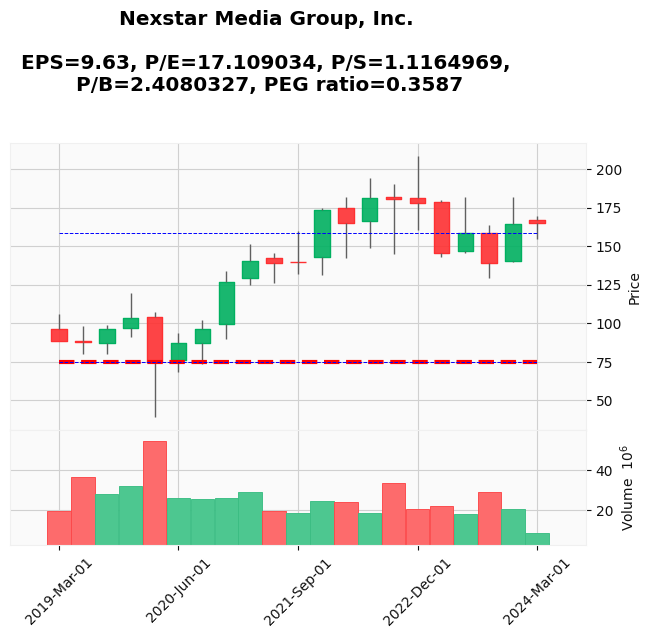

## TMUS - T-Mobile US, Inc.

https://www.t-mobile.com


Market Cap: 190623.186944 Millions USD

|    | Title                                                                                                                                                            | Publisher           |   Sentiment |   Days Ago |
|---:|:-----------------------------------------------------------------------------------------------------------------------------------------------------------------|:--------------------|------------:|-----------:|
|  0 | [16 Most Undervalued Large Cap Stocks To Buy According To Analysts](https://finance.yahoo.com/news/16-most-undervalued-large-cap-144247052.html)                 | Insider Monkey      |    0.357143 |          0 |
|  1 | [T-Mobile Helps Drive Local Change With Over $12 Million in Hometown Grants](https://finance.yahoo.com/news/t-mobile-helps-drive-local-141500402.html)           | ACCESSWIRE          |    0        |          2 |
|  2 | [Telekom Deutsche Sells Shares of T-Mobile US Inc (TMUS)](https://finance.yahoo.com/news/telekom-deutsche-sells-shares-t-052815256.html)                         | GuruFocus.com       |    0        |          2 |
|  3 | [T-Mobile Un-Carrier All-Star Spotlight: Dr. Jie Hui](https://finance.yahoo.com/news/t-mobile-un-carrier-star-134500116.html)                                    | ACCESSWIRE          |    0        |          4 |
|  4 | [Navigating Market Uncertainty: Intrinsic Value of T-Mobile US Inc](https://finance.yahoo.com/news/navigating-market-uncertainty-intrinsic-value-120013220.html) | GuruFocus.com       |    0        |          4 |
|  5 | [Why wireless companies are struggling to monetize 5G investments](https://finance.yahoo.com/video/why-wireless-companies-struggling-monetize-214932261.html)    | Yahoo Finance Video |    0        |          5 |
|  6 | [T-Mobile's Network Ready to Shine During Solar Eclipse 2024](https://finance.yahoo.com/news/t-mobiles-network-ready-shine-141500258.html)                       | ACCESSWIRE          |    0.2      |          5 |
|  7 | [T-Mobile Un-Carrier All-Star Spotlight: Ronke Ekwensi](https://finance.yahoo.com/news/t-mobile-un-carrier-star-134000402.html)                                  | ACCESSWIRE          |    0        |          6 |

| Metric           | Value                                |
|:-----------------|:-------------------------------------|
| Dividend Date    | 2024-06-13                           |
| Ex-Dividend Date | 2024-05-31                           |
| Earnings Date    | ['April 25, 2024', 'April 29, 2024'] |
| Earnings High    | 2.19                                 |
| Earnings Low     | 1.79                                 |
| Earnings Average | 1.91                                 |
| Revenue High     | 20,585,000,000.00                    |
| Revenue Low      | 19,267,000,000.00                    |
| Revenue Average  | 19,900,500,000.00                    |

T-Mobile US, Inc., together with its subsidiaries, provides mobile communications services in the United States, Puerto Rico, and the United States Virgin Islands. The company offers voice, messaging, and data services to customers in the postpaid, prepaid, and wholesale and other services. It also provides wireless devices, including smartphones, wearables, tablets, home broadband routers, and other mobile communication devices, as well as wireless devices and accessories; financing through equipment installment plans; reinsurance for device insurance policies and extended warranty contracts; leasing through JUMP! On Demand; and High Speed Internet services. In addition, the company offers services, devices, and accessories under the T-Mobile and Metro by T-Mobile brands through its owned and operated retail stores, T-Mobile app and customer care channels, and its websites. It also sells its devices to dealers and other third-party distributors for resale through independent third-party retail outlets and various third-party websites. The company was founded in 1994 and is headquartered in Bellevue, Washington.

<Figure size 640x480 with 0 Axes>

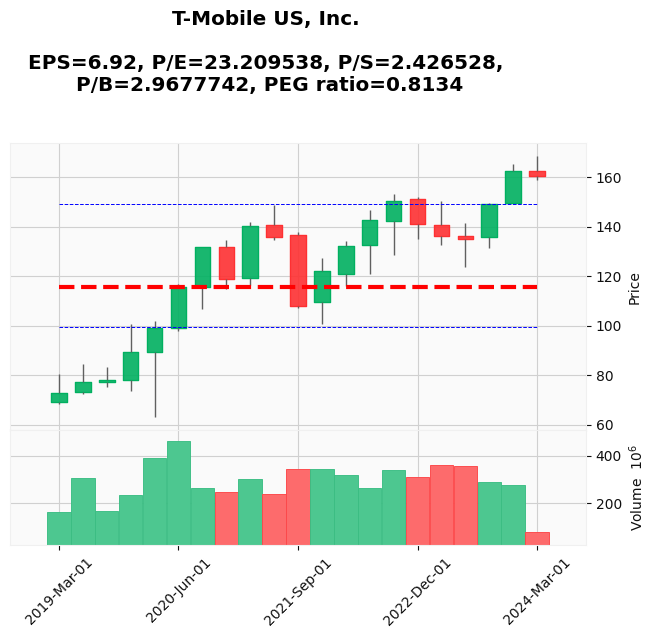

# Sector: Healthcare

## JNJ - Johnson & Johnson

https://www.jnj.com


Market Cap: 374070.14912 Millions USD

|    | Title                                                                                                                                                                             | Publisher       |   Sentiment |   Days Ago |
|---:|:----------------------------------------------------------------------------------------------------------------------------------------------------------------------------------|:----------------|------------:|-----------:|
|  0 | [13 Best Dividend-Paying Stocks Under $15](https://finance.yahoo.com/news/13-best-dividend-paying-stocks-150455707.html)                                                          | Insider Monkey  |   1         |          0 |
|  1 | [14 Best Medical Device Stocks To Buy Now](https://finance.yahoo.com/news/14-best-medical-device-stocks-133625148.html)                                                           | Insider Monkey  |   0.5       |          0 |
|  2 | [Johnson & Johnson (NYSE:JNJ) shareholders have earned a 4.9% CAGR over the last five years](https://finance.yahoo.com/news/johnson-johnson-nyse-jnj-shareholders-110112732.html) | Simply Wall St. |   0         |          0 |
|  3 | [19 Most Densely Populated States in the US](https://finance.yahoo.com/news/19-most-densely-populated-states-090743247.html)                                                      | Insider Monkey  |   0.5       |          2 |
|  4 | [Want Decades of Passive Income? 2 Stocks to Buy Now.](https://finance.yahoo.com/m/04a06f57-2695-3845-a2d4-38f3e3e435bb/want-decades-of-passive.html)                             | Motley Fool     |   0         |          2 |
|  5 | [UPDATE 3-US FDA classifies corrections to instructions for Abiomed's blood pumps as most serious](https://finance.yahoo.com/news/1-us-fda-classifies-recall-150532370.html)      | Reuters         |   0.0833333 |          3 |
|  6 | [Abiomed’s latest Impella recall linked to 129 injury, 49 death reports](https://finance.yahoo.com/m/5ec4c319-cf6b-31ca-8344-9e6728fc7ea3/abiomed%E2%80%99s-latest-impella.html)  | MedTech Dive    |   0.5       |          3 |
|  7 | [11 Best Healthcare ETFs To Buy Now](https://finance.yahoo.com/news/11-best-healthcare-etfs-buy-142503468.html)                                                                   | Insider Monkey  |   1         |          3 |

| Metric           | Value              |
|:-----------------|:-------------------|
| Dividend Date    | 2024-03-05         |
| Ex-Dividend Date | 2024-02-16         |
| Earnings Date    | ['April 16, 2024'] |
| Earnings High    | 2.74               |
| Earnings Low     | 2.44               |
| Earnings Average | 2.63               |
| Revenue High     | 21,797,300,000.00  |
| Revenue Low      | 21,105,000,000.00  |
| Revenue Average  | 21,403,700,000.00  |

Johnson & Johnson, together with its subsidiaries, researches, develops, manufactures, and sells various products in the healthcare field worldwide. The company's Innovative Medicine segment offers products for various therapeutic areas, such as immunology, including rheumatoid arthritis, psoriatic arthritis, inflammatory bowel disease, and psoriasis; infectious diseases comprising HIV/AIDS; neuroscience, consisting of mood disorders, neurodegenerative disorders, and schizophrenia; oncology, such as prostate cancer, hematologic malignancies, lung cancer, and bladder cancer; cardiovascular and metabolism, including thrombosis, diabetes, and macular degeneration; and pulmonary hypertension comprising pulmonary arterial hypertension through retailers, wholesalers, distributors, hospitals, and healthcare professionals for prescription use. Its MedTech segment provides Interventional Solutions, including electrophysiology products to treat heart rhythm disorders; the heart recovery portfolio, which includes technologies to treat severe coronary artery disease requiring high-risk PCI or AMI cardiogenic shock; and neurovascular care that treats hemorrhagic and ischemic stroke. this segment also offers an orthopaedics portfolio that includes products and enabling technologies that support hips, knees, trauma, spine, sports, and other; surgery portfolios comprising advanced and general surgery technologies, as well as solutions for breast aesthetics, ear, nose, and throat procedures; contact lenses under the ACUVUE Brand; and TECNIS intraocular lenses for cataract surgery. It distributes its products to wholesalers, hospitals, and retailers, as well as physicians, nurses, hospitals, eye care professionals, and clinics. Johnson & Johnson was founded in 1886 and is based in New Brunswick, New Jersey.

<Figure size 640x480 with 0 Axes>

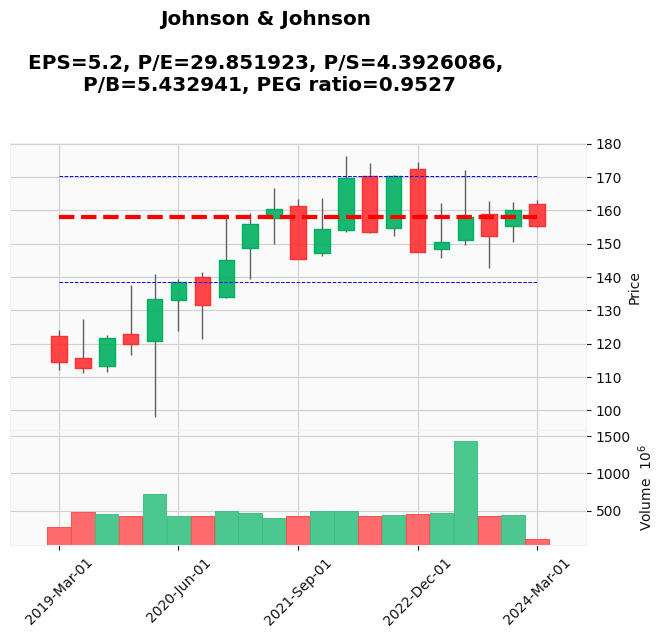

## VRTX - Vertex Pharmaceuticals Incorpor

https://www.vrtx.com


Market Cap: 107368.300544 Millions USD

|    | Title                                                                                                                                                                                                                                                       | Publisher                    |   Sentiment |   Days Ago |
|---:|:------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------|:-----------------------------|------------:|-----------:|
|  0 | [Vertex (VRTX) Kidney Disease Drug to Enter Clinical Development](https://finance.yahoo.com/news/vertex-vrtx-kidney-disease-drug-160900770.html)                                                                                                            | Zacks                        |    0        |          2 |
|  1 | [Vertex Announces FDA Clearance of Investigational New Drug Application for VX-407 for the Treatment of Autosomal Dominant Polycystic Kidney Disease (ADPKD)](https://finance.yahoo.com/news/vertex-announces-fda-clearance-investigational-120000049.html) | Business Wire                |    0.136364 |          3 |
|  2 | [Vertex Pharmaceuticals (VRTX) Beats Stock Market Upswing: What Investors Need to Know](https://finance.yahoo.com/news/vertex-pharmaceuticals-vrtx-beats-stock-215018713.html)                                                                              | Zacks                        |    0        |          6 |
|  3 | [2 No-Brainer Healthcare Stocks to Buy With $1,000 Right Now](https://finance.yahoo.com/m/90bd9c54-c773-3e55-b325-b9fd51203284/2-no-brainer-healthcare.html)                                                                                                | Motley Fool                  |    0.285714 |          7 |
|  4 | [3 Unstoppable Stocks You Can Buy Now Without Any Hesitation](https://finance.yahoo.com/m/0da2d7b3-5f7a-317b-82ac-80dcf1fd58c1/3-unstoppable-stocks-you-can.html)                                                                                           | Motley Fool                  |    0        |          7 |
|  5 | [Forget Tesla, Buy This Magnificent Healthcare Stock Instead](https://finance.yahoo.com/m/9b2f3c5e-6c06-3c73-b45d-2844f694791b/forget-tesla%2C-buy-this.html)                                                                                               | Motley Fool                  |    1        |          7 |
|  6 | [Is It Too Late to Buy CRISPR Therapeutics Stock?](https://finance.yahoo.com/m/6b5bdbd1-eb39-3611-a5e6-3ab85e7429c5/is-it-too-late-to-buy-crispr.html)                                                                                                      | Motley Fool                  |   -0.3      |          8 |
|  7 | [Q4 2023 MaxCyte Inc Earnings Call](https://finance.yahoo.com/news/q4-2023-maxcyte-inc-earnings-115601296.html)                                                                                                                                             | Thomson Reuters StreetEvents |    0        |         11 |

| Metric           | Value                              |
|:-----------------|:-----------------------------------|
| Earnings Date    | ['April 29, 2024', 'May 03, 2024'] |
| Earnings High    | 4.08                               |
| Earnings Low     | 3.1                                |
| Earnings Average | 3.72                               |
| Revenue High     | 2,426,540,000.00                   |
| Revenue Low      | 2,158,340,000.00                   |
| Revenue Average  | 2,367,200,000.00                   |

Vertex Pharmaceuticals Incorporated, a biotechnology company, engages in developing and commercializing therapies for treating cystic fibrosis (CF). It markets TRIKAFTA/KAFTRIO for people with CF with at least one F508del mutation for 2 years of age or older; SYMDEKO/SYMKEVI for people with CF for 6 years of age or older;  ORKAMBI for CF patients 1 year or older; and KALYDECO for the treatment of patients with 1 year or older who have CF with ivacaftor. The company's pipeline includes VX-522, a CFTR mRNA therapeutic designed to treat the underlying cause of CF, which is in Phase 1 clinical trial; VX-548, a non-opioid medicine for the treatment of acute and neuropathic pain which is in Phase 3 clinical trial; Exa-cel, for the treatment of sickle cell disease and transfusion-dependent beta thalassemia which is in Phase 2/3 clinical trial. In addition, it provides inaxaplin for the treatment of APOL1-mediated focal segmental glomerulosclerosis and co-morbidities, such as hypertension which is in single Phase 2/3; VX- 880 and VX-264, treatment for Type 1 Diabetes which is in Phase 1/2 clinical trial;  VX-970, which is in Phase 2 clinical trial for the treatment of cancer; and VX-803 and VX-984 for treatment of cancer in Phase 1 clinical trial. Further, it sells the products to specialty pharmacy and specialty distributors in the United States, as well as retail pharmacies, hospitals, and clinics. Additionally, the company has collaborations with CRISPR Therapeutics AG.; Moderna, Inc.; Entrada Therapeutics, Inc.; Arbor Biotechnologies, Inc.; Mammoth Biosciences, Inc.; and Verve Therapeutics., as well as collaborations with Tevard Biosciences to develop novel tRNA-based therapies for duchenne muscular dystrophy. Vertex Pharmaceuticals Incorporated was founded in 1989 and is headquartered in Boston, Massachusetts.

<Figure size 640x480 with 0 Axes>

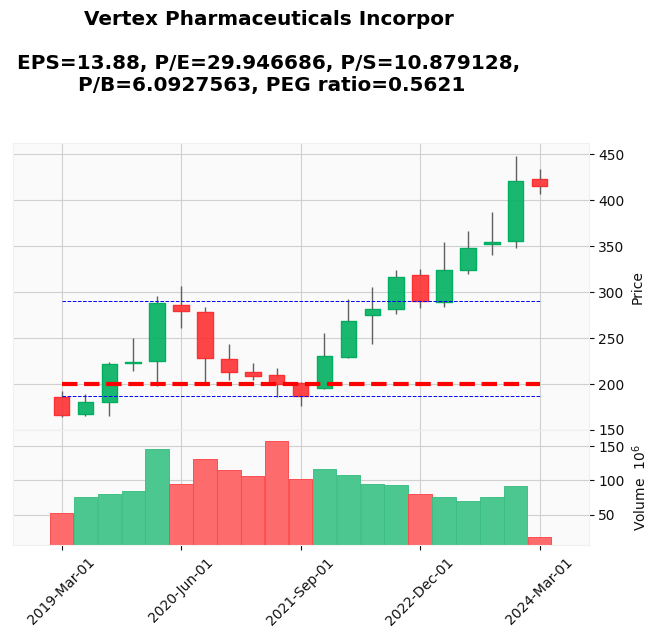

<Figure size 640x480 with 0 Axes>

In [22]:
def get_eps_pe_pb_ps_peg(ticker_symbol):
    try:
        if ticker_symbol in combined_metrics['company_labels']:
            index = combined_metrics['company_labels'].index(ticker_symbol)
            eps = combined_metrics['eps_values'][index]
            pe = combined_metrics['pe_values'][index]
            ps = combined_metrics['ps_values'][index]
            pb = combined_metrics['pb_values'][index]
            peg = combined_metrics['peg_values'][index]

            return eps, pe, ps, pb, peg
        else:
            print(f"Ticker '{ticker_symbol}' not found in the labels list.")
            return None, None, None, None, None
    except Exception as e:
        print(f"An error occurred: {e}")
        return None, None, None, None, None

def calculate_market_profile(data):
    mp = MarketProfile(data)
    mp_slice = mp[data.index.min():data.index.max()]

    va_high, va_low = mp_slice.value_area
    poc_price = mp_slice.poc_price
    profile_range = mp_slice.profile_range

    return va_high, va_low, poc_price, profile_range

def plot_with_volume_profile(ticker_symbol, start_date, end_date):
    ticker = yf.Ticker(ticker_symbol)
    data = fetch_historical_data(ticker, start_date, end_date)

    eps, pe, ps, pb, peg = get_eps_pe_pb_ps_peg(ticker_symbol)

    if not data.empty:
        va_high, va_low, poc_price, _ = calculate_market_profile(data)

        poc_line = pd.Series(poc_price, index=data.index)
        va_high_line = pd.Series(va_high, index=data.index)
        va_low_line = pd.Series(va_low, index=data.index)

        apds = [mpf.make_addplot(poc_line, type='line', color='red', linestyle='dashed', width=3),
                mpf.make_addplot(va_high_line, type='line', color='blue', linestyle='dashed', width=0.7),
                mpf.make_addplot(va_low_line, type='line', color='blue', linestyle='dashed', width=0.7)]

        title = (f"{ticker.info['shortName']}\n\n"
                 f" EPS={eps}, P/E={pe}, P/S={ps}, \n P/B={pb}, PEG ratio={peg}\n\n\n")

        mpf.plot(data, type="candle", addplot=apds, title=title, style="yahoo", volume=True, show_nontrading=False)
    else:
        print(f"No data found for {ticker_symbol} in the given date range.")

def plot_candle_charts_per_sector(industries, start_date, end_date):
    for sector, symbol_list in industries.items():
        display(Markdown(f"# Sector: {sector}"))
        for symbol in symbol_list:
            display(Markdown(f"## {symbol} - {yf.Ticker(symbol).info['shortName']}"))
            
            # Website
            print(yf.Ticker(symbol).info['website'])
            
            # Market Cap
            display(Markdown(f"Market Cap: {yf.Ticker(symbol).info['marketCap']/1000000} Millions USD"))

            # News
            try:
                ndata = yf.Ticker(symbol).news
                news_data = []
                for item in ndata:
                    publish_datetime = datetime.fromtimestamp(item['providerPublishTime'])
                    now = datetime.now()
                    days_ago = (now - publish_datetime).days
                    blob = TextBlob(item['title'])
                    polarity = blob.sentiment.polarity
                    news_data.append({
                        'Title': f"[{item['title']}]({item['link']})",
                        'Publisher': item['publisher'],
                        'Sentiment': polarity,
                        'Days Ago': days_ago 
                    }) 

                table_str = tabulate(news_data, headers="keys", tablefmt="pipe", showindex="always")
                display(Markdown(table_str))

            except:
                print(f"An error occurred when trying to fetch data for {symbol}")
                
            # Calendar
            data = yf.Ticker(symbol).calendar
            data['Earnings Date'] = [date.strftime('%B %d, %Y') for date in data['Earnings Date']]
            for key, value in data.items():
                if key.startswith('Revenue') and isinstance(value, int):
                    data[key] = '{:,.2f}'.format(value)
            table = [[key] + [val] for key, val in data.items()]
            table_str = tabulate(table, headers=["Metric", "Value"], tablefmt="pipe")
            display(Markdown(table_str))

            # Business Desc
            display(Markdown(f"{yf.Ticker(symbol).info['longBusinessSummary']}"))
            
            # Plot Chart
            plot_with_volume_profile(symbol, start_date, end_date)
            
            plt.tight_layout()
    
    plt.show()

plot_candle_charts_per_sector(filtered_industries, start_date_str, end_date_str)